In [76]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("SamplePortfolio.csv")
print(f"The dataset has {len(df)} rows and {len(df.columns)} columns")
print(df.head())

The dataset has 533 rows and 24 columns
   POSITIONS            UNIQUE ID ID TYPE                                NAME  \
0        NaN  CX_US4642851053_NYQ    ISIN                  iShares Gold Trust   
1        NaN  CX_US0584981064_NYQ    ISIN                           BALL CORP   
2        NaN  CX_IE00BY7QL619_NYQ    ISIN  JOHNSON CONTROLS INTERNATIONAL PLC   
3        NaN  CX_US1912161007_NYQ    ISIN                           COCA-COLA   
4        NaN  CX_US46434G1031_NYQ    ISIN  iShares Core MSCI Emerging Markets   

          PORTFOLIO  POSITION UNITS  HAS_LOOKTHROUGH  FUND_NAV  PRICE  \
0  Sample Portfolio             100            False       NaN  11.95   
1  Sample Portfolio             100            False       NaN  42.42   
2  Sample Portfolio             100            False       NaN  44.00   
3  Sample Portfolio             100            False       NaN  44.67   
4  Sample Portfolio             100            False       NaN  52.23   

  CURRENCY  ... esg_Controversy es

In [77]:
sector_counts = df["sector"].value_counts()
sector_counts = sector_counts.head(10)
print("Top 10 sectors:")
print(sector_counts)

Top 10 sectors:
sector
Consumer Discretionary    83
Information Technology    74
Industrials               73
Financials                68
Health Care               67
Consumer Staples          34
Energy                    34
Real Estate               33
Utilities                 29
Materials                 25
Name: count, dtype: int64


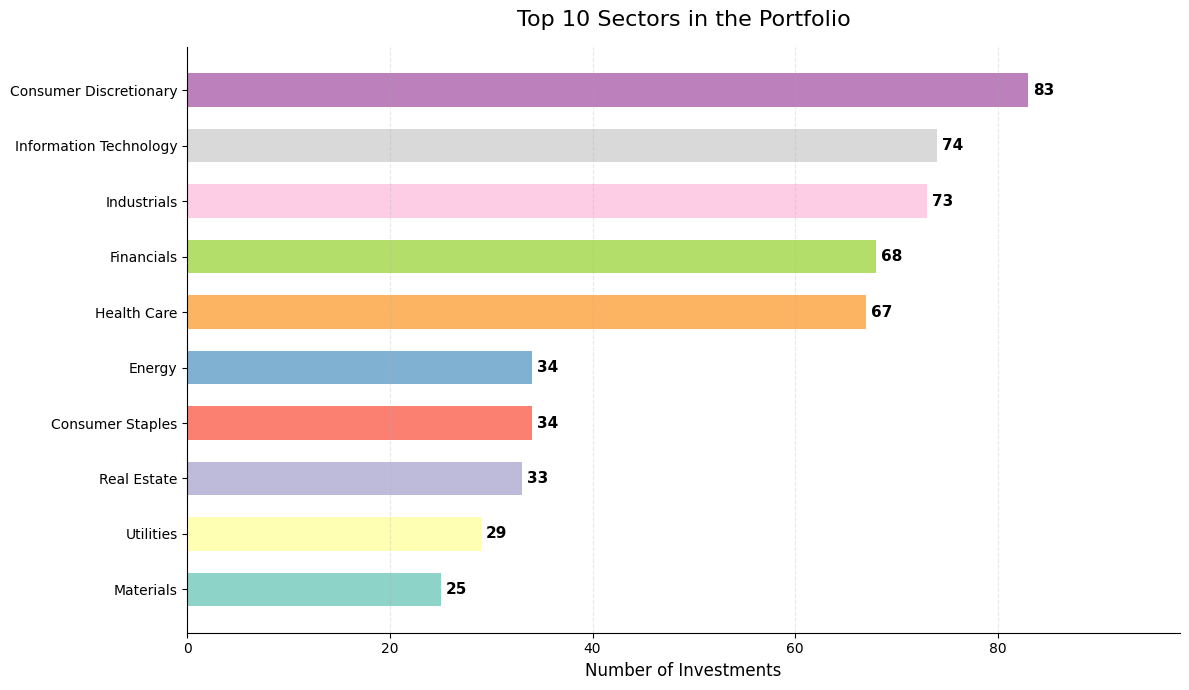

In [78]:
sector_sorted = sector_counts.sort_values(ascending=True)
plt.figure(figsize=(12, 7))
bars = plt.barh(sector_sorted.index, sector_sorted.values, color=colors, height=0.6)

for i, value in enumerate(sector_sorted.values):
    plt.text(value + 0.5, i, str(value), va="center", fontsize=11, fontweight="bold")


plt.title("Top 10 Sectors in the Portfolio", fontsize=16, pad=15)

plt.xlabel("Number of Investments", fontsize=12)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.grid(axis="x", alpha=0.3, linestyle="--")

plt.xlim(0, sector_sorted.max() + 15)
plt.savefig("chart1_TOP10_Sectors.png", bbox_inches="tight", dpi=150)
plt.tight_layout()
plt.show()

In [79]:
esg_columns = ["esg_Environmental", "esg_Governance", "esg_Social", "esg_Sustainability", "esg_Controversy"]
esg_averages = df[esg_columns].mean()
print("Average ESG scores across the portfolio:")
print(esg_averages.round(2))

Average ESG scores across the portfolio:
esg_Environmental     5.48
esg_Governance        5.39
esg_Social            5.48
esg_Sustainability    5.48
esg_Controversy       5.63
dtype: float64


In [80]:
controversy_columns = ["has_Tobacco", "has_Alcohol", "has_Gambling", "has_Military", "has_Fossil Fuels"]
controversy_counts = df[controversy_columns].sum()
controversy_counts.index = ["Tobacco", "Alcohol", "Gambling", "Military", "Fossil Fuels"]
print("Number of companies flagged per category:")
print(controversy_counts)

Number of companies flagged per category:
Tobacco          6
Alcohol          4
Gambling         6
Military        18
Fossil Fuels    38
dtype: int64


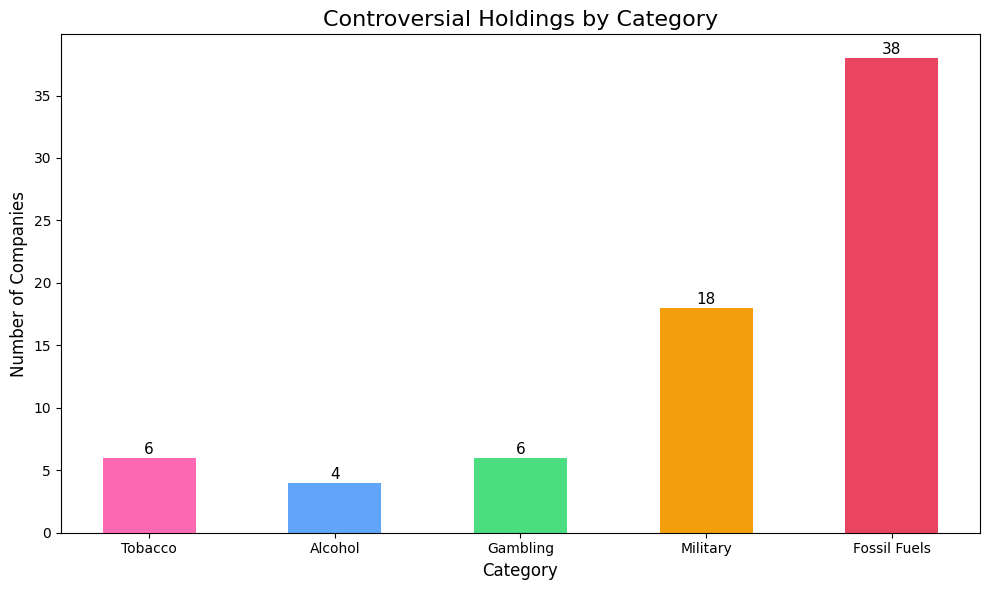

In [81]:
plt.figure(figsize=(10, 6))
colors = ["#ff69b4", "#60a5fa", "#4ade80", "#f59e0b", "#e94560"]
plt.bar(controversy_counts.index, controversy_counts.values, color=colors, width=0.5)
plt.title("Controversial Holdings by Category", fontsize=16)
plt.xlabel("Category", fontsize=12)
plt.ylabel("Number of Companies", fontsize=12)
for i, value in enumerate(controversy_counts.values):
    plt.text(i, value + 0.3, str(value), ha="center", fontsize=11)
plt.savefig("chart2_Controversial_Holdings.png", dpi=150)

plt.tight_layout()
plt.show()

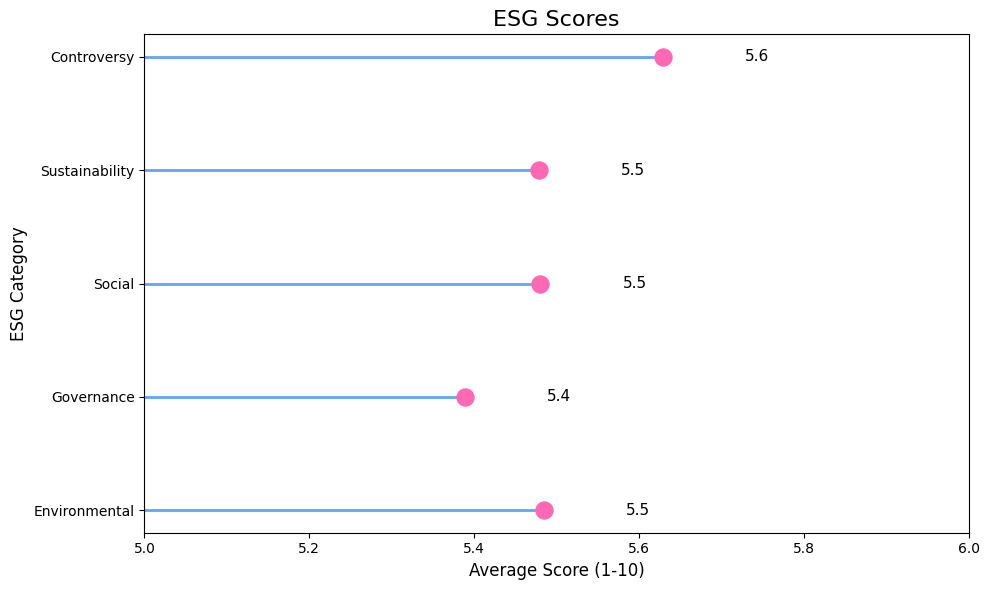

In [82]:
plt.figure(figsize=(10, 6))
labels = ["Environmental", "Governance", "Social", "Sustainability", "Controversy"]
values = esg_averages.values
plt.hlines(labels, 0, values, color="#60a5fa", linewidth=2)
plt.scatter(values, labels, color="#ff69b4", s=150, zorder=3)
plt.title("ESG Scores", fontsize=16)
plt.xlabel("Average Score (1-10)", fontsize=12)
plt.ylabel("ESG Category", fontsize=12)
plt.xlim(5, 6)
for i, value in enumerate(values):
    plt.text(value + 0.1, i, f"{value:.1f}", va="center", fontsize=11)
    
    plt.savefig("chart4_ESG.png", bbox_inches="tight" , dpi=150)

plt.tight_layout()
plt.show()

In [83]:

df_prices = df.dropna(subset=["PRICE"])
df_prices = df_prices.groupby("NAME")["PRICE"].max().reset_index()
top10_prices = df_prices.sort_values("PRICE", ascending=False).head(10)
print("Top 10 most expensive stocks:")
print(top10_prices)

Top 10 most expensive stocks:
                           NAME    PRICE
80         BOOKING HOLDINGS INC  2010.60
31               AMAZON COM INC  1812.97
28         ALPHABET INC CLASS A  1199.10
29         ALPHABET INC CLASS C  1186.96
266      INTUITIVE SURGICAL INC   946.65
62                 AUTOZONE INC   716.17
318          METTLER TOLEDO INC   598.11
77                BLACKROCK INC   504.89
111  CHIPOTLE MEXICAN GRILL INC   454.83
182            EQUINIX REIT INC   437.19


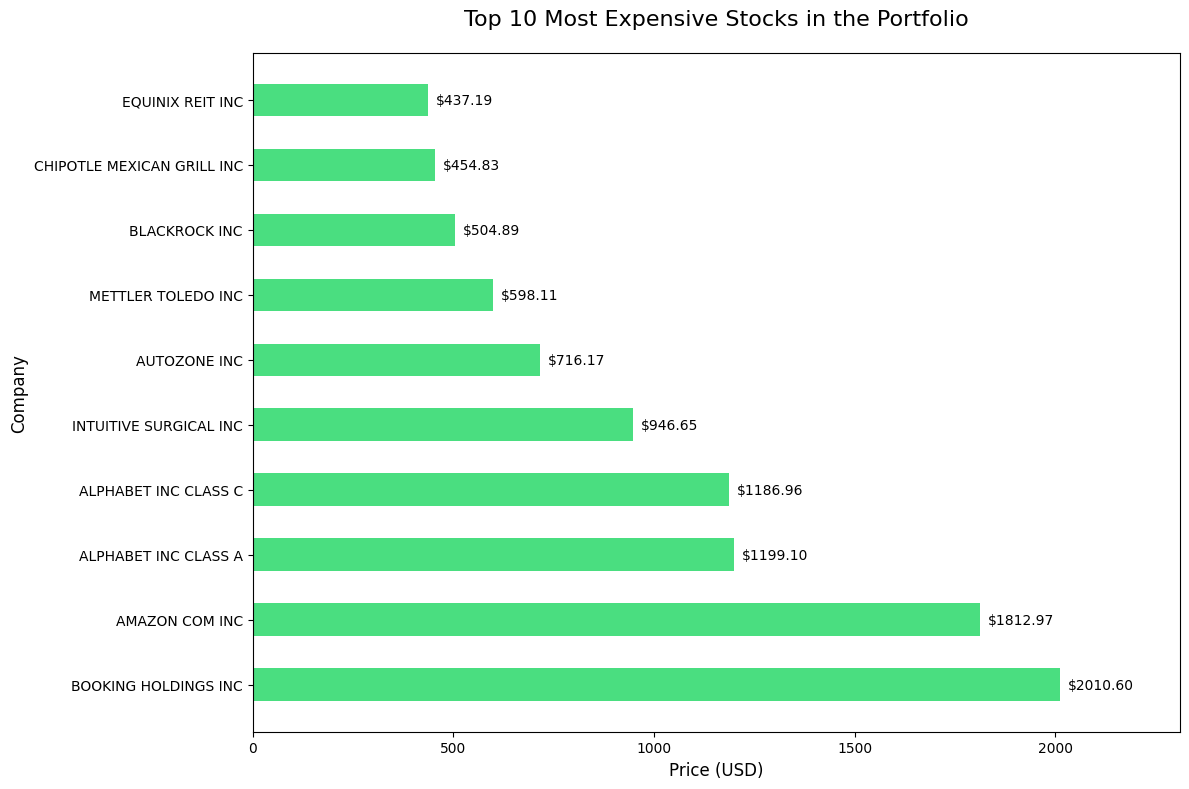

In [84]:

df_prices = df.dropna(subset=["PRICE"])
df_prices = df_prices.groupby("NAME")["PRICE"].max().reset_index()
top10_prices = df_prices.sort_values("PRICE", ascending=False).head(10)
fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(top10_prices["NAME"], top10_prices["PRICE"], color="#4ade80", height=0.5)
ax.set_title("Top 10 Most Expensive Stocks in the Portfolio", fontsize=16, pad=20)
ax.set_xlabel("Price (USD)", fontsize=12)
ax.set_ylabel("Company", fontsize=12)
ax.set_xlim(0, top10_prices["PRICE"].max() + 300)
for i, value in enumerate(top10_prices["PRICE"]):
    ax.text(value + 20, i, f"${value:.2f}", va="center", fontsize=10)

plt.savefig("chart4_Top10_Expensive.png", bbox_inches="tight" , dpi=150)

plt.tight_layout()
plt.show()


In [85]:
avg_price_per_sector = df.groupby("sector")["PRICE"].mean()
avg_price_per_sector = avg_price_per_sector.sort_values(ascending=False)
avg_price_per_sector = avg_price_per_sector.round(2)
print("Average stock price per sector:")
print(avg_price_per_sector)

Average stock price per sector:
sector
Health Care                162.16
Consumer Discretionary     147.63
Information Technology     136.39
Industrials                119.25
Diversified                107.61
Materials                  103.18
Real Estate                 98.69
Financials                  96.34
Consumer Staples            77.11
Energy                      73.13
Utilities                   61.34
Cash and/or Derivatives     50.50
Telecommunications          33.75
Commodity                   11.95
Name: PRICE, dtype: float64


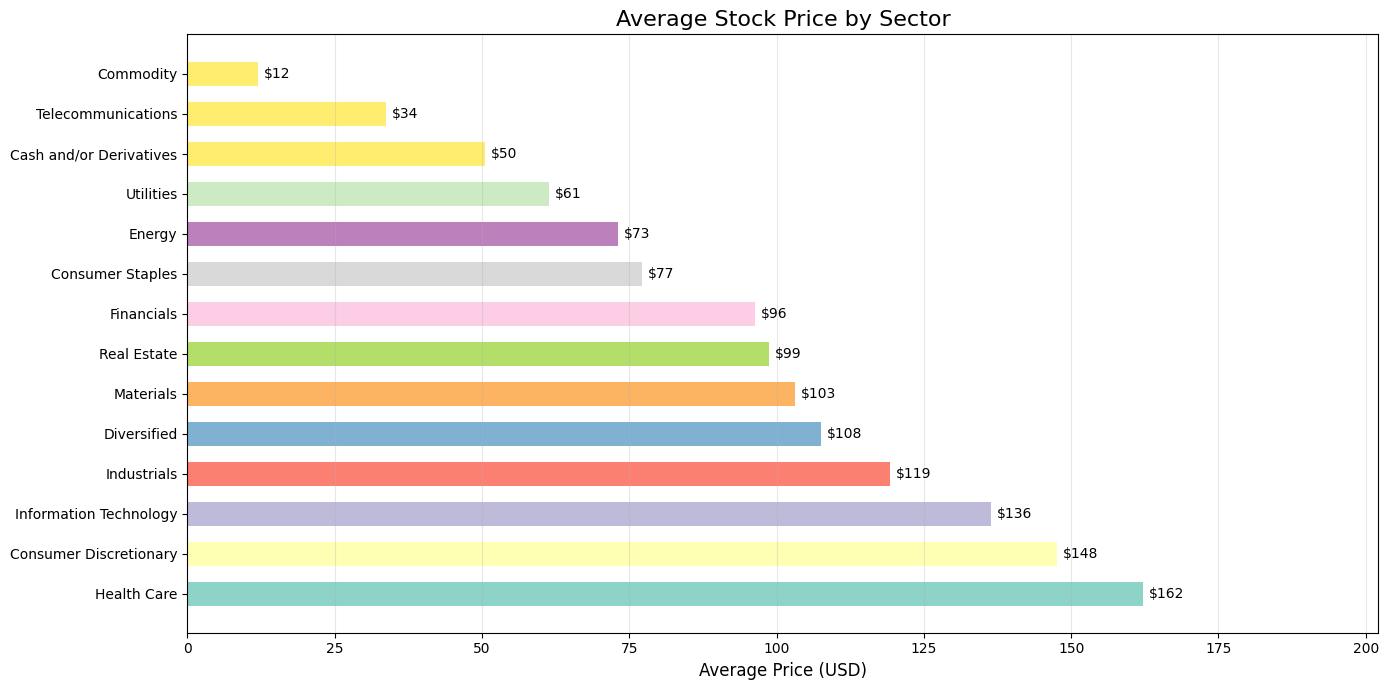

In [86]:
plt.figure(figsize=(14, 7))

colors = plt.cm.Set3(range(len(avg_price_per_sector)))

bars = plt.barh(avg_price_per_sector.index, avg_price_per_sector.values, 
                color=colors, height=0.6)

for i, value in enumerate(avg_price_per_sector.values):
    plt.text(value + 1, i, f"${value:.0f}", va="center", fontsize=10)

plt.title("Average Stock Price by Sector", fontsize=16)
plt.xlabel("Average Price (USD)", fontsize=12)

plt.grid(axis="x", alpha=0.3)

plt.xlim(0, avg_price_per_sector.max() + 40)
plt.savefig("chart5_Avg_stock_price.png", bbox_inches="tight", dpi=150)

plt.tight_layout()
plt.show()

In [87]:
import subprocess
subprocess.run(["jupyter", "nbconvert", "--to", "html", "analysis.ipynb"])

print

[NbConvertApp] Converting notebook analysis.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 5 image(s).
[NbConvertApp] Writing 588580 bytes to analysis.html


<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [88]:
html = """<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <title>Portfolio Analysis</title>
    <link href="https://fonts.googleapis.com/css2?family=Inter:wght@400;600;700;900&display=swap" rel="stylesheet">
    <style>
        * { margin: 0; padding: 0; box-sizing: border-box; }
        body { font-family: 'Inter', sans-serif; background: #0a0a0f; color: #e0e0e0; padding: 40px; }
        h1 { font-size: 36px; font-weight: 900; color: #ffffff; text-align: center; margin-bottom: 8px; }
        .subtitle { text-align: center; color: #6b6b80; margin-bottom: 50px; font-size: 14px; }
        .section { margin-bottom: 60px; }
        .section h2 { font-size: 20px; font-weight: 700; color: #e94560; margin-bottom: 8px; letter-spacing: 1px; text-transform: uppercase; }
        .section p { color: #6b6b80; font-size: 14px; margin-bottom: 16px; }
        .section img { width: 100%; border-radius: 12px; border: 1px solid #ffffff15; }
        hr { border: none; border-top: 1px solid #ffffff10; margin-bottom: 60px; }
        footer { text-align: center; color: #3a3a4a; font-size: 12px; margin-top: 40px; }
    </style>
</head>
<body>

<h1>Portfolio Analysis</h1>
<p class="subtitle">SamplePortfolio.csv — 533 investments analysed using Python</p>

<div class="section">
    <h2>Top 10 Sectors</h2>
    <p>Which industries are most represented in the portfolio?</p>
    <img src="chart1_sectors.png">
</div>
<hr>

<div class="section">
    <h2>Average Stock Price by Sector</h2>
    <p>Which sectors have the most expensive stocks on average?</p>
    <img src="chart5_Avg_stock_price.png">
</div>
<hr>

<div class="section">
    <h2>ESG Scores</h2>
    <p>How ethical and sustainable are the investments? Scores range from 1 to 10.</p>
    <img src="chart3_ESG.png">
</div>
<hr>

<div class="section">
    <h2>Controversial Holdings</h2>
    <p>How many companies are flagged for controversial activities?</p>
    <img src="chart2_Controversial_Holdings.png">
</div>
<hr>

<div class="section">
    <h2>Top 10 Most Expensive Stocks</h2>
    <p>The most expensive individual stocks in the portfolio by share price.</p>
    <img src="chart4_Top10_Expensive.png">
</div>

<footer>Data Analysis and Artificial Intelligence — Dr. Mindaugas Sarpis — 2026</footer>

</body>
</html>"""

with open("index.html", "w", encoding="utf-8") as f:
    f.write(html)

print("Website created! Open index.html in your browser!")

Website created! Open index.html in your browser!


In [89]:
html = """<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <title>Portfolio Analysis</title>
    <link href="https://fonts.googleapis.com/css2?family=Inter:wght@300;400;600;700;900&display=swap" rel="stylesheet">
    <style>
        * { margin: 0; padding: 0; box-sizing: border-box; }
        body { font-family: 'Inter', sans-serif; background: #0a0a0f; color: #e0e0e0; }
        .hero { padding: 60px 40px 40px; text-align: center; border-bottom: 1px solid #ffffff10; }
        .hero-tag { display: inline-block; background: #e9456020; border: 1px solid #e9456050; color: #e94560; padding: 5px 16px; border-radius: 50px; font-size: 11px; font-weight: 700; letter-spacing: 2px; text-transform: uppercase; margin-bottom: 20px; }
        .hero h1 { font-size: 42px; font-weight: 900; color: #fff; margin-bottom: 10px; }
        .hero p { color: #6b6b80; font-size: 15px; }
        .nav { display: flex; justify-content: center; gap: 8px; padding: 24px 40px; border-bottom: 1px solid #ffffff10; flex-wrap: wrap; }
        .nav button { background: #12121a; border: 1px solid #ffffff15; color: #6b6b80; font-size: 13px; font-weight: 600; padding: 10px 20px; border-radius: 10px; cursor: pointer; font-family: 'Inter', sans-serif; transition: all 0.2s; }
        .nav button:hover { color: #fff; border-color: #ffffff30; }
        .nav button.active { background: #e9456020; border-color: #e94560; color: #e94560; }
        .content { max-width: 1000px; margin: 0 auto; padding: 50px 40px; }
        .panel { display: none; }
        .panel.active { display: block; }
        .panel-title { font-size: 11px; font-weight: 700; letter-spacing: 3px; text-transform: uppercase; color: #e94560; margin-bottom: 8px; }
        .panel-heading { font-size: 28px; font-weight: 800; color: #fff; margin-bottom: 12px; }
        .panel-desc { color: #6b6b80; font-size: 14px; line-height: 1.7; margin-bottom: 30px; max-width: 600px; }
        .chart-box { background: #12121a; border: 1px solid #ffffff10; border-radius: 16px; overflow: hidden; margin-bottom: 24px; }
        .chart-box img { width: 100%; display: block; }
        .stats { display: grid; grid-template-columns: repeat(4, 1fr); gap: 16px; margin-bottom: 40px; }
        .stat { background: #12121a; border: 1px solid #ffffff10; border-radius: 12px; padding: 24px; text-align: center; }
        .stat .num { font-size: 36px; font-weight: 900; color: #4ade80; }
        .stat .lbl { font-size: 11px; color: #6b6b80; font-weight: 600; text-transform: uppercase; letter-spacing: 1px; margin-top: 4px; }
        footer { text-align: center; color: #2a2a3a; font-size: 12px; padding: 30px; border-top: 1px solid #ffffff08; }
    </style>
</head>
<body>
<div class="hero">
    <div class="hero-tag">Data Analysis Project</div>
    <h1>Portfolio Analysis</h1>
    <p>533 investments analysed using Python — pandas & matplotlib</p>
</div>
<div class="nav">
    <button class="active" onclick="show('overview', this)">Overview</button>
    <button onclick="show('sectors', this)">Sectors</button>
    <button onclick="show('prices', this)">Prices</button>
    <button onclick="show('esg', this)">ESG Scores</button>
    <button onclick="show('controversial', this)">Controversial</button>
</div>
<div class="content">
    <div class="panel active" id="panel-overview">
        <p class="panel-title">Summary</p>
        <h2 class="panel-heading">Key Numbers</h2>
        <p class="panel-desc">A high level overview of the portfolio. Click the tabs above to explore each analysis in detail.</p>
        <div class="stats">
            <div class="stat"><div class="num">533</div><div class="lbl">Total Investments</div></div>
            <div class="stat"><div class="num">5.5</div><div class="lbl">Avg ESG Score</div></div>
            <div class="stat"><div class="num">64</div><div class="lbl">Flagged Holdings</div></div>
            <div class="stat"><div class="num">12</div><div class="lbl">Sectors</div></div>
        </div>
        <div class="chart-box"><img src="chart1_TOP10_Sectors.png"></div>
    </div>
    <div class="panel" id="panel-sectors">
        <p class="panel-title">Breakdown</p>
        <h2 class="panel-heading">Top 10 Sectors</h2>
        <p class="panel-desc">Which industries are most represented in the portfolio? Consumer Discretionary leads with 83 holdings.</p>
        <div class="chart-box"><img src="chart1_TOP10_Sectors.png"></div>
    </div>
    <div class="panel" id="panel-prices">
        <p class="panel-title">Price Analysis</p>
        <h2 class="panel-heading">Stock Prices</h2>
        <p class="panel-desc">Booking Holdings is the most expensive stock at $2,010 per share. Health Care has the highest average price per sector.</p>
        <div class="chart-box"><img src="chart4_Top10_Expensive.png"></div>
        <div class="chart-box"><img src="chart5_Avg_stock_price.png"></div>
    </div>
    <div class="panel" id="panel-esg">
        <p class="panel-title">Sustainability</p>
        <h2 class="panel-heading">ESG Scores</h2>
        <p class="panel-desc">ESG scores measure how ethical and sustainable a company is, on a scale from 1 to 10. The portfolio averages around 5.5 across all categories.</p>
        <div class="chart-box"><img src="chart4_ESG.png"></div>
    </div>
    <div class="panel" id="panel-controversial">
        <p class="panel-title">Risk Screening</p>
        <h2 class="panel-heading">Controversial Holdings</h2>
        <p class="panel-desc">64 companies (12% of the portfolio) are flagged for tobacco, alcohol, gambling, military, or fossil fuels.</p>
        <div class="chart-box"><img src="chart2_Controversial_Holdings.png"></div>
    </div>
</div>
<footer>Data Analysis and Artificial Intelligence &mdash; Dr. Mindaugas Sarpis &mdash; 2026</footer>
<script>
function show(id, btn) {
    document.querySelectorAll('.panel').forEach(p => p.classList.remove('active'));
    document.querySelectorAll('.nav button').forEach(b => b.classList.remove('active'));
    document.getElementById('panel-' + id).classList.add('active');
    btn.classList.add('active');
    window.scrollTo(0, 0);
}
</script>
</body>
</html>"""

with open("index.html", "w", encoding="utf-8") as f:
    f.write(html)

print("Done! Open index.html in your browser!")

Done! Open index.html in your browser!
